# RecordDiff: Mechanism Plausibility & Privacy

## 1 · Setup

In [ ]:
import os, time, numpy as np, torch, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)
if device == "cpu":
    print("WARNING: enable GPU — Phase D trains two model variants.")

torch 2.11.0+cu128 | device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2 · Configuration

In [ ]:
V2_CACHE  = "..."
CKPT_MNAR = "..."
CKPT_MAR  = "..."

HOLDOUT_FRAC = 0.30
N_SYNTH      = 8000
D_C_FALLBACK = 8
D_Z, D_E, D_RNN, D_COMB, H_MASK, H_DEN, D_U, N_DIFF = 64, 128, 128, 128, 256, 512, 8, 100
EPOCHS_D  = (12, 6, 12)
BATCH, LR, BETA_MAX, LAMBDA_M, FREE_BITS, WINS = 256, 1e-3, 0.5, 1.0, 0.05, (0.005, 0.995)
DELTA_GRID = np.linspace(-1.5, 1.5, 13)
SENS_VARS  = ["Lactate", "Creatinine", "Troponin_T", "Glucose_lab"]
SEED = 0
rng = np.random.default_rng(SEED)
print("holdout", HOLDOUT_FRAC, "| N_synth", N_SYNTH, "| schedule", EPOCHS_D)

Phase D config | holdout 0.3 | N_synth 8000 | schedule (12, 6, 12)


## 3 · Model core (embedded, includes the MAR policy switch)

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# utils
def timestep_embedding(t, dim):
    """Sinusoidal embedding of diffusion step t:(B,) -> (B,dim)."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / max(half, 1))
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        emb = F.pad(emb, (0, 1))
    return emb


def causal_hist(m):
    """m:(B,T,V) {0,1} -> (B,T,2V): [count-before-t / T, steps-since-last-obs-before-t / T].
    Strictly causal (uses only t' < t), matching the incremental generation-time update."""
    B, T, V = m.shape
    csum = torch.cumsum(m, dim=1)
    count_excl = csum - m
    idx = torch.arange(T, device=m.device).view(1, T, 1).float().expand(B, T, V)
    obs_pos = torch.where(m > 0.5, idx, torch.full_like(m, -1.0))
    shifted = torch.cat([torch.full((B, 1, V), -1.0, device=m.device), obs_pos[:, :-1, :]], dim=1).contiguous()
    last_obs_excl = torch.cummax(shifted, dim=1).values
    dt = idx - last_obs_excl
    return torch.cat([count_excl / T, dt / T], dim=-1)


class DiffusionSchedule:
    """Standard DDPM linear-beta schedule with precomputed coefficients."""
    def __init__(self, n_steps=100, beta_start=1e-4, beta_end=2e-2):
        betas = torch.linspace(beta_start, beta_end, n_steps)
        alphas = 1.0 - betas
        abar = torch.cumprod(alphas, dim=0)
        abar_prev = torch.cat([torch.ones(1), abar[:-1]])
        self.n_steps = n_steps
        self.betas = betas
        self.alphas = alphas
        self.abar = abar
        self.sqrt_abar = torch.sqrt(abar)
        self.sqrt_one_minus_abar = torch.sqrt(1.0 - abar)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
        self.posterior_var = betas * (1.0 - abar_prev) / (1.0 - abar)

    def to(self, device):
        for k, v in list(self.__dict__.items()):
            if torch.is_tensor(v):
                setattr(self, k, v.to(device))
        return self

    def q_sample(self, x0, t, noise):
        sa = self.sqrt_abar[t].view(-1, 1, 1)
        soma = self.sqrt_one_minus_abar[t].view(-1, 1, 1)
        return sa * x0 + soma * noise


class Denoiser(nn.Module):
    """Predicts diffusion noise per timestep: eps_theta(x_noisy, cond, t). Applied vectorised over T."""
    def __init__(self, V, d_cond, d_temb=64, hidden=256):
        super().__init__()
        self.d_temb = d_temb
        self.net = nn.Sequential(
            nn.Linear(V + d_cond + d_temb, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, V),
        )

    def forward(self, x, cond, t):
        temb = timestep_embedding(t, self.d_temb)
        temb = temb[:, None, :].expand(-1, x.shape[1], -1)
        return self.net(torch.cat([x, cond, temb], dim=-1))

# model
class RecordDiff(nn.Module):
    def __init__(self, V, d_c=8, d_z=32, d_e=128, d_rnn=128, d_comb=128,
                 hidden_mask=256, hidden_den=256, d_temb=64, n_diff=100, d_u=8, mar_mode=False):
        super().__init__()
        self.V, self.d_c, self.d_z, self.d_u = V, d_c, d_z, d_u
        self.mar_mode = mar_mode
        self.diff = DiffusionSchedule(n_diff)

        self.emb = nn.Sequential(nn.Linear(2 * V, d_e), nn.SiLU(), nn.Linear(d_e, d_e))
        self.bigru = nn.GRU(d_e, d_rnn, batch_first=True, bidirectional=True)
        self.comb_z = nn.Linear(d_z, d_comb)
        self.comb_g = nn.Linear(2 * d_rnn, d_comb)
        self.q_mu = nn.Linear(d_comb, d_z)
        self.q_ls = nn.Linear(d_comb, d_z)
        if d_u > 0:
            self.u_mu = nn.Linear(2 * d_rnn, d_u)
            self.u_ls = nn.Linear(2 * d_rnn, d_u)
        self.p0_mu = nn.Linear(d_c, d_z)
        self.p0_ls = nn.Linear(d_c, d_z)
        self.tr_body = nn.Sequential(nn.Linear(d_z + d_c, d_comb), nn.SiLU())
        self.tr_mu = nn.Linear(d_comb, d_z)
        self.tr_ls = nn.Linear(d_comb, d_z)
        self.mask_head = nn.Sequential(
            nn.Linear(d_z + d_c + 2 * V + d_u, hidden_mask), nn.SiLU(),
            nn.Linear(hidden_mask, hidden_mask), nn.SiLU(),
            nn.Linear(hidden_mask, V))
        self.d_cond = d_z + d_c + V + 2 * V
        self.denoiser = Denoiser(V, self.d_cond, d_temb, hidden_den)
        self.register_buffer("norm_mean", torch.zeros(V))
        self.register_buffer("norm_std", torch.ones(V))

    def params_encoder(self):
        mods = [self.emb, self.bigru, self.comb_z, self.comb_g, self.q_mu, self.q_ls,
                self.p0_mu, self.p0_ls, self.tr_body, self.tr_mu, self.tr_ls]
        if self.d_u > 0:
            mods += [self.u_mu, self.u_ls]
        return [p for mod in mods for p in mod.parameters()]

    def params_value(self):
        return list(self.denoiser.parameters())

    def params_mask(self):
        return list(self.mask_head.parameters())

    def set_normalizer(self, mean, std):
        self.norm_mean.data = mean.to(self.norm_mean.device)
        self.norm_std.data = std.clamp(min=1e-3).to(self.norm_std.device)

    def _prior_step(self, z_prev, c, t):
        if t == 0:
            return self.p0_mu(c), self.p0_ls(c)
        body = self.tr_body(torch.cat([z_prev, c], dim=-1))
        return z_prev + self.tr_mu(body), self.tr_ls(body)

    def infer(self, y, m, c):
        """Amortised posterior over z_{1:T} and the patient random effect u.
        Returns Z, KL_z, u, KL_u (all latent KLs against their priors)."""
        B, T, V = y.shape
        e = self.emb(torch.cat([y, m], dim=-1))
        g, _ = self.bigru(e)
        if self.d_u > 0:
            gpool = g.mean(1)
            mu_u, ls_u = self.u_mu(gpool), self.u_ls(gpool)
            std_u = F.softplus(ls_u) + 1e-4
            u = mu_u + std_u * torch.randn_like(std_u)
            kl_u = (-torch.log(std_u) + 0.5 * (std_u ** 2 + mu_u ** 2) - 0.5)
        else:
            u = torch.zeros(B, 0, device=y.device)
            kl_u = torch.zeros(B, 0, device=y.device)
        z_prev = torch.zeros(B, self.d_z, device=y.device)
        Zs, KLs = [], []
        for t in range(T):
            hc = 0.5 * (torch.tanh(self.comb_z(z_prev)) + self.comb_g(g[:, t, :]))
            mu_q, ls_q = self.q_mu(hc), self.q_ls(hc)
            mu_p, ls_p = self._prior_step(z_prev, c, t)
            std_q = F.softplus(ls_q) + 1e-4
            std_p = F.softplus(ls_p) + 1e-4
            z = mu_q + std_q * torch.randn_like(std_q)
            kl = (torch.log(std_p / std_q)
                  + (std_q ** 2 + (mu_q - mu_p) ** 2) / (2 * std_p ** 2) - 0.5)
            Zs.append(z); KLs.append(kl)
            z_prev = z
        Z = torch.stack(Zs, dim=1)
        KL = torch.stack(KLs, dim=1)
        return Z, KL, u, kl_u

    def losses(self, y, m, c, free_bits=0.02):
        """y assumed already normalised; m in {0,1}; c:(B,d_c). Returns loss dict."""
        B, T, V = y.shape
        hist = causal_hist(m)
        Z, KL, u, kl_u = self.infer(y, m, c)
        c_seq = c[:, None, :].expand(-1, T, -1)
        u_seq = u[:, None, :].expand(-1, T, -1)

        Z_pol = torch.zeros_like(Z) if self.mar_mode else Z
        u_pol = torch.zeros_like(u_seq) if self.mar_mode else u_seq
        mask_logits = self.mask_head(torch.cat([Z_pol, c_seq, hist, u_pol], dim=-1))
        L_mask = F.binary_cross_entropy_with_logits(mask_logits, m)

        x0 = y
        tau = torch.randint(0, self.diff.n_steps, (B,), device=y.device)
        noise = torch.randn_like(x0)
        x_noisy = self.diff.q_sample(x0, tau, noise)
        cond = torch.cat([Z, c_seq, m, hist], dim=-1)
        eps_pred = self.denoiser(x_noisy, cond, tau)
        se = (eps_pred - noise) ** 2
        L_value = (se * m).sum() / m.sum().clamp(min=1.0)

        KL_fb = (torch.clamp(KL, min=free_bits).sum(-1).mean()
                 + torch.clamp(kl_u, min=free_bits).sum(-1).mean())
        return {"L_value": L_value, "L_mask": L_mask, "KL": KL_fb}

    # generation
    @torch.no_grad()
    def _ddpm_sample(self, cond):
        """Reverse DDPM for a single timestep. cond:(n,d_cond) -> x:(n,V) (normalised)."""
        n = cond.shape[0]
        dev = cond.device
        x = torch.randn(n, 1, self.V, device=dev)
        cond1 = cond[:, None, :]
        for i in reversed(range(self.diff.n_steps)):
            tau = torch.full((n,), i, dtype=torch.long, device=dev)
            eps = self.denoiser(x, cond1, tau)
            mean = self.diff.sqrt_recip_alphas[i] * (
                x - self.diff.betas[i] / self.diff.sqrt_one_minus_abar[i] * eps)
            if i > 0:
                x = mean + torch.sqrt(self.diff.posterior_var[i]) * torch.randn_like(x)
            else:
                x = mean
        return x[:, 0, :]

    @torch.no_grad()
    def generate(self, n, c, T, denorm=True, return_x=False):
        """Ancestral sample of recorded reality. Returns (Y, M) [+ complete X if return_x],
        denormalised if denorm=True. X is the pre-mask complete value tensor."""
        dev = c.device
        V = self.V
        count_run = torch.zeros(n, V, device=dev)
        last_obs = -torch.ones(n, V, device=dev)
        z_prev = torch.zeros(n, self.d_z, device=dev)
        u = torch.randn(n, self.d_u, device=dev) if self.d_u > 0 else torch.zeros(n, 0, device=dev)
        M = torch.zeros(n, T, V, device=dev)
        Y = torch.zeros(n, T, V, device=dev)
        X = torch.zeros(n, T, V, device=dev) if return_x else None
        for t in range(T):
            mu_p, ls_p = self._prior_step(z_prev, c, t)
            z = mu_p + (F.softplus(ls_p) + 1e-4) * torch.randn_like(mu_p)
            hist = torch.cat([count_run / T, (t - last_obs) / T], dim=-1)
            z_pol = torch.zeros_like(z) if self.mar_mode else z
            u_pol = torch.zeros_like(u) if self.mar_mode else u
            m_t = torch.bernoulli(torch.sigmoid(self.mask_head(torch.cat([z_pol, c, hist, u_pol], dim=-1))))
            x_t = self._ddpm_sample(torch.cat([z, c, m_t, hist], dim=-1))
            if denorm:
                x_t = x_t * self.norm_std + self.norm_mean
            M[:, t, :] = m_t
            Y[:, t, :] = m_t * x_t
            if return_x:
                X[:, t, :] = x_t
            last_obs = torch.where(m_t > 0.5, torch.full_like(last_obs, float(t)), last_obs)
            count_run = count_run + m_t
            z_prev = z
        return (Y, M, X) if return_x else (Y, M)

# data helpers
def fit_normalizer(y, m):
    """Per-variable mean/std over observed (m==1) entries. y,m:(N,T,V) tensors."""
    V = y.shape[-1]
    mean = torch.zeros(V); std = torch.ones(V)
    for v in range(V):
        vals = y[:, :, v][m[:, :, v] > 0.5]
        if vals.numel() > 10:
            mean[v] = vals.mean()
            std[v] = vals.std().clamp(min=1e-3)
    return mean, std


def normalize(y, m, mean, std):
    yn = (y - mean) / std
    return yn * m


def set_requires_grad(params, flag):
    for p in params:
        p.requires_grad_(flag)


def train_recorddiff(model, y, m, c, epochs=(8, 4, 8), batch=256, lr=1e-3,
                     beta_max=1.0, lambda_m=1.0, free_bits=0.02, val_frac=0.1,
                     clip=5.0, device="cpu", seed=0, verbose=True):
    """3-phase amortised-VI training.
        Phase 1 (representation): encoder + value diffusion + prior,  loss = L_value + beta*KL
        Phase 2 (policy):         freeze the above, train mask head,   loss = L_mask
        Phase 3 (joint):          everything,  loss = L_value + lambda_m*L_mask + beta_max*KL
    y is RAW (normalised internally via model.norm_*). Returns loss history."""
    torch.manual_seed(seed)
    model.to(device); model.diff.to(device)
    N = y.shape[0]
    perm = torch.randperm(N)
    n_val = int(N * val_frac)
    val_idx, tr_idx = perm[:n_val], perm[n_val:]
    e1, e2, e3 = epochs
    total = e1 + e2 + e3
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mean, std = model.norm_mean.cpu(), model.norm_std.cpu()
    hist = {"phase": [], "L_value": [], "L_mask": [], "KL": [], "val_total": []}

    def run_batches(idx, train=True):
        agg = {"L_value": 0.0, "L_mask": 0.0, "KL": 0.0, "tot": 0.0, "nb": 0}
        order = idx[torch.randperm(len(idx))] if train else idx
        for s in range(0, len(order), batch):
            bi = order[s:s + batch]
            yb = normalize(y[bi], m[bi], mean, std).to(device)
            mb = m[bi].to(device)
            cb = c[bi].to(device)
            out = model.losses(yb, mb, cb, free_bits=free_bits)
            if phase == 1:
                loss = out["L_value"] + beta * out["KL"]
            elif phase == 2:
                loss = out["L_mask"]
            else:
                loss = out["L_value"] + lambda_m * out["L_mask"] + beta_max * out["KL"]
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip); opt.step()
            for k in ("L_value", "L_mask", "KL"):
                agg[k] += float(out[k].detach())
            agg["tot"] += float(loss.detach()); agg["nb"] += 1
        for k in ("L_value", "L_mask", "KL", "tot"):
            agg[k] /= max(agg["nb"], 1)
        return agg

    for ep in range(total):
        if ep < e1:
            phase = 1; beta = beta_max * min(1.0, (ep + 1) / max(e1, 1))
            set_requires_grad(model.params_encoder(), True)
            set_requires_grad(model.params_value(), True)
            set_requires_grad(model.params_mask(), False)
        elif ep < e1 + e2:
            phase = 2; beta = beta_max
            set_requires_grad(model.params_encoder(), False)
            set_requires_grad(model.params_value(), False)
            set_requires_grad(model.params_mask(), True)
        else:
            phase = 3; beta = beta_max
            set_requires_grad(model.params_encoder(), True)
            set_requires_grad(model.params_value(), True)
            set_requires_grad(model.params_mask(), True)

        model.train(); tr = run_batches(tr_idx, train=True)
        model.eval()
        with torch.no_grad():
            va = run_batches(val_idx, train=False) if n_val > 0 else tr
        hist["phase"].append(phase)
        hist["L_value"].append(tr["L_value"]); hist["L_mask"].append(tr["L_mask"])
        hist["KL"].append(tr["KL"]); hist["val_total"].append(va["tot"])
        if verbose:
            print(f"ep {ep:3d} | phase {phase} | "
                  f"L_value {tr['L_value']:.4f}  L_mask {tr['L_mask']:.4f}  KL {tr['KL']:.4f} "
                  f"| val_total {va['tot']:.4f}")
    return hist

# synthetic
def make_synthetic(n=512, T=12, V=6, seed=0, device="cpu"):
    """Toy MNAR data: latent severity drives both values and (informatively) the mask."""
    g = torch.Generator().manual_seed(seed)
    sev = torch.rand(n, 1, 1, generator=g)
    base = torch.randn(n, 1, V, generator=g)
    drift = torch.linspace(0, 1, T).view(1, T, 1) * (sev - 0.5) * 4.0
    x = base + drift + 0.3 * torch.randn(n, T, V, generator=g)
    logit = -0.5 + 2.0 * sev + 0.6 * (x > 1.0).float() + 0.4 * torch.randn(n, T, V, generator=g)
    m = torch.bernoulli(torch.sigmoid(logit), generator=g)
    y = x * m
    c = torch.cat([sev.view(n, 1), torch.randn(n, 7, generator=g)], dim=-1)
    return y.to(device), m.to(device), c.to(device)


## 4 · Mechanism + privacy helpers (embedded, validated)

In [ ]:
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# featurizers
def mask_features(m):
    N, T, V = m.shape
    count = m.sum(1).astype(np.float32); rate = count / T
    obs = m > 0.5
    first = np.where(obs.any(1), np.argmax(obs, 1), T).astype(np.float32) / T
    rev = obs[:, ::-1, :]
    last = (np.where(obs.any(1), (T - 1 - np.argmax(rev, 1)), -1.0).astype(np.float32) + 1.0) / T
    return np.concatenate([count, rate, first, last], axis=1).astype(np.float32)


def value_features(y, m):
    N, T, V = y.shape
    obs = m > 0.5; cnt = np.maximum(m.sum(1), 1)
    mean = (y.sum(1) / cnt).astype(np.float32)
    std = np.sqrt(np.maximum((y * y).sum(1) / cnt - mean ** 2, 0.0)).astype(np.float32)
    ao = obs.any(1)
    vmin = np.where(ao, np.where(obs, y, np.inf).min(1), 0.0).astype(np.float32)
    vmax = np.where(ao, np.where(obs, y, -np.inf).max(1), 0.0).astype(np.float32)
    rev = obs[:, ::-1, :]; lt = np.where(ao, T - 1 - np.argmax(rev, 1), 0)
    last = np.where(ao, np.take_along_axis(y, lt[:, None, :], 1)[:, 0, :], 0.0).astype(np.float32)
    return np.nan_to_num(np.concatenate([mean, std, vmin, vmax, last], axis=1))


def channel_features(m, y, channel):
    parts = []
    if channel in ("mask", "joint"):
        parts.append(mask_features(m))
    if channel in ("value", "joint"):
        parts.append(value_features(y, m))
    return np.nan_to_num(np.concatenate(parts, axis=1))

# privacy: DCR + MIA
def _standardize(fit_on, *arrs):
    sc = StandardScaler().fit(fit_on)
    return [sc.transform(a) for a in arrs]


def _nn_dist(A, B):
    """min Euclidean distance from each row of A to the rows of B."""
    d, _ = NearestNeighbors(n_neighbors=1).fit(B).kneighbors(A)
    return d.ravel()


def dcr(feat_synth, feat_train, feat_holdout):
    """Distance-to-closest-record of synthetic vs train and vs holdout (standardized)."""
    ft = np.vstack([feat_train, feat_holdout])
    fs, ftr, fho = _standardize(ft, feat_synth, feat_train, feat_holdout)
    d_train = _nn_dist(fs, ftr)
    d_hold = _nn_dist(fs, fho)
    return d_train, d_hold


def mia_auroc(feat_train, feat_holdout, feat_synth):
    """Distance-based membership inference: score = -dist(real -> nearest synthetic).
    AUROC of (train=member) vs (holdout=non-member). 0.5 = private."""
    ref = np.vstack([feat_train, feat_holdout])
    ftr, fho, fs = _standardize(ref, feat_train, feat_holdout, feat_synth)
    s_tr = -_nn_dist(ftr, fs); s_ho = -_nn_dist(fho, fs)
    y = np.r_[np.ones(len(s_tr)), np.zeros(len(s_ho))]
    return float(roc_auc_score(y, np.r_[s_tr, s_ho]))

# privacy: mask uniqueness / k-anonymity
def mask_pattern(m, mode="binary", cap=5):
    """Coarsen each record's mask into a pattern for uniqueness analysis."""
    if mode == "binary":
        pat = (m.sum(1) > 0).astype(int)
    else:
        pat = np.minimum(m.sum(1).astype(int), cap)
    return pat


def kanonymity(pat):
    """k for each row = number of records sharing its pattern; returns k array."""
    keys = [tuple(r) for r in pat]
    cnt = Counter(keys)
    return np.array([cnt[k] for k in keys])


def linkage_unique_rate(pat_synth, pat_real):
    """Fraction of synthetic patterns that match exactly one real record (re-id surface)."""
    cnt = Counter(tuple(r) for r in pat_real)
    return float(np.mean([cnt.get(tuple(r), 0) == 1 for r in pat_synth]))

# privacy: attribute inference
def attribute_inference_auroc(m_tr, y_tr, a_tr, m_te, y_te, a_te, channel, seed=0):
    """Attacker trained on SYNTHETIC to predict a sensitive attribute, tested on REAL.
    channel controls the attacker's feature set (value vs joint reveals mask leakage)."""
    Xtr = channel_features(m_tr, y_tr, channel); Xte = channel_features(m_te, y_te, channel)
    sc = StandardScaler().fit(Xtr)
    clf = HistGradientBoostingClassifier(max_depth=4, max_iter=150, random_state=seed)
    clf.fit(sc.transform(Xtr), a_tr)
    return float(roc_auc_score(a_te, clf.predict_proba(sc.transform(Xte))[:, 1]))

# mechanism: delta-selection sensitivity
def delta_adjusted_mean(x_obs, z_obs, delta):
    """Selection-model IPW estimate of a variable's population mean under an assumed
    value->missingness coupling delta. delta=0 -> naive observed mean; delta>0 assumes
    high-value entries were over-observed (down-weights them)."""
    w = np.exp(-delta * z_obs)
    w = np.clip(w, 1e-6, 1e6)
    return float(np.sum(w * x_obs) / np.sum(w))


def severity_score(y, m, var_class, weights={"protocol": 0.3, "acuity": 0.6, "triggered": 1.0}):
    """Per-record acuity proxy: taxonomy-weighted standardized value projection over observed."""
    N, T, V = y.shape
    obs = m > 0.5; cnt = np.maximum(m.sum((0, 1)), 1)
    mu = (y * obs).sum((0, 1)) / cnt
    sd = np.sqrt(np.maximum(((y - mu) ** 2 * obs).sum((0, 1)) / cnt, 1e-6))
    w = np.array([weights[c] for c in var_class], np.float32)
    per = (((y - mu) / sd) * obs).sum(1) / np.maximum(m.sum(1), 1)
    return (per * w).sum(1) / w.sum()


## 5 · Smoke test

In [ ]:
ys, ms, cs = make_synthetic(n=400, T=10, V=6, seed=0)
def _tiny(mar):
    mm = RecordDiff(V=6, d_c=8, d_z=8, d_e=32, d_rnn=32, d_comb=32,
                    hidden_mask=64, hidden_den=64, d_temb=32, n_diff=15, d_u=4, mar_mode=mar).to(device)
    mm.diff.to(device); mm.set_normalizer(*fit_normalizer(ys, ms))
    train_recorddiff(mm, ys, ms, cs, epochs=(2, 1, 2), batch=128, beta_max=0.5, free_bits=0.05,
                     device=device, verbose=False)
    mm.eval(); mm.diff.to(device)
    Y, M = mm.generate(400, torch.zeros(400, 8, device=device), T=10)
    return M.cpu().numpy(), Y.cpu().numpy()
Mn, Yn = _tiny(False); Ma, Ya = _tiny(True)
vc = ["protocol", "protocol", "acuity", "acuity", "triggered", "triggered"]
mia = mia_auroc(channel_features(ms.numpy(), ys.numpy(), "joint"),
                channel_features(Ma, Ya, "joint"), channel_features(Mn, Yn, "joint"))
sev = severity_score(Yn, Mn, vc)
assert 0.0 <= mia <= 1.0 and np.isfinite(sev).all() and Mn.shape == (400, 10, 6), "smoke failed"
print(f"SMOKE OK — MNAR+MAR train/generate + MIA({mia:.2f}) + severity run cleanly.")

SMOKE OK — MNAR+MAR train/generate + MIA(0.00) + severity run cleanly.


## 6 · Load cohort, split real train / holdout


In [ ]:
d = np.load(V2_CACHE, allow_pickle=True)
m_all, y_all = d["m"].astype(np.float32), d["y"].astype(np.float32)
VAR_NAMES = list(d["var_names"]); VAR_CLASS = [str(x) for x in d["var_class"]]
N, T, V = m_all.shape
c_all = d["c"].astype(np.float32) if "c" in d.files else np.zeros((N, D_C_FALLBACK), np.float32)
D_C = c_all.shape[1] if c_all.shape[1] > 0 else D_C_FALLBACK
if c_all.shape[1] == 0:
    c_all = np.zeros((N, D_C), np.float32)
labels = {t: d[f"lab_{t}"].astype(int) for t in ["mortality_inhosp", "icu_mortality"] if f"lab_{t}" in d.files}

strat = labels.get("mortality_inhosp", None)
tr_idx, ho_idx = train_test_split(np.arange(N), test_size=HOLDOUT_FRAC, stratify=strat, random_state=SEED)

m_w, y_w = m_all.copy(), y_all.copy()
for v in range(V):
    obs = y_all[tr_idx][:, :, v][m_all[tr_idx][:, :, v] > 0.5]
    if obs.size > 200:
        lo, hi = np.quantile(obs, WINS); y_w[:, :, v] = np.clip(y_w[:, :, v], lo, hi) * m_all[:, :, v]

m_tr, y_tr, c_tr = m_w[tr_idx], y_w[tr_idx], c_all[tr_idx]
m_ho, y_ho = m_w[ho_idx], y_w[ho_idx]
print(f"train {len(tr_idx)} | holdout {len(ho_idx)} | V={V} d_c={D_C}")
print("variable classes:", {k: VAR_CLASS.count(k) for k in set(VAR_CLASS)})

train 21799 | holdout 9343 | V=36 d_c=11
variable classes: {'acuity': 17, 'triggered': 12, 'protocol': 7}


---
# Part 1 · Mechanism Plausibility

## 1.1 · Train MNAR + MAR variants and generate

In [ ]:
m_tr_t, y_tr_t, c_tr_t = torch.from_numpy(m_tr), torch.from_numpy(y_tr), torch.from_numpy(c_tr)
def train_variant(mar, ckpt):
    mdl = RecordDiff(V=V, d_c=D_C, d_z=D_Z, d_e=D_E, d_rnn=D_RNN, d_comb=D_COMB, hidden_mask=H_MASK,
                     hidden_den=H_DEN, d_temb=64, n_diff=N_DIFF, d_u=D_U, mar_mode=mar).to(device)
    mdl.diff.to(device); mn, sd = fit_normalizer(y_tr_t, m_tr_t); mdl.set_normalizer(mn, sd)
    print(f"training {'MAR' if mar else 'MNAR'} variant ...")
    train_recorddiff(mdl, y_tr_t, m_tr_t, c_tr_t, epochs=EPOCHS_D, batch=BATCH, lr=LR, beta_max=BETA_MAX,
                     lambda_m=LAMBDA_M, free_bits=FREE_BITS, device=device, seed=SEED, verbose=True)
    torch.save({"state_dict": mdl.state_dict(),
                "config": dict(V=V, d_c=D_C, d_z=D_Z, d_e=D_E, d_rnn=D_RNN, d_comb=D_COMB,
                               hidden_mask=H_MASK, hidden_den=H_DEN, d_temb=64, n_diff=N_DIFF,
                               d_u=D_U, mar_mode=mar), "norm_mean": mn, "norm_std": sd}, ckpt)
    return mdl

t0 = time.time()
mnar = train_variant(False, CKPT_MNAR)
mar = train_variant(True, CKPT_MAR)
print(f"\nboth variants trained in {(time.time()-t0)/60:.1f} min")

sidx = rng.choice(len(tr_idx), size=min(N_SYNTH, len(tr_idx)), replace=False)
c_syn = torch.from_numpy(c_tr[sidx]).to(device)
def generate(mdl):
    mdl.eval(); mdl.diff.to(device)
    with torch.no_grad():
        Y, M, X = mdl.generate(len(sidx), c_syn, T, return_x=True)
    M, X = M.cpu().numpy(), X.cpu().numpy()
    for v in range(V):
        obs = y_all[tr_idx][:, :, v][m_all[tr_idx][:, :, v] > 0.5]
        if obs.size > 200:
            lo, hi = np.quantile(obs, WINS); X[:, :, v] = np.clip(X[:, :, v], lo, hi)
    return M, (M * X).astype(np.float32), X
M_mnar, Y_mnar, X_mnar = generate(mnar)
M_mar, Y_mar, X_mar = generate(mar)
print(f"generated {len(sidx)} records from each variant")

training MNAR variant ...
ep   0 | phase 1 | L_value 0.7767  L_mask 0.6933  KL 14.6201 | val_total 0.8987
ep   1 | phase 1 | L_value 0.6457  L_mask 0.6929  KL 3.8349 | val_total 0.9288
ep   2 | phase 1 | L_value 0.5804  L_mask 0.6927  KL 3.7261 | val_total 1.0226
ep   3 | phase 1 | L_value 0.5603  L_mask 0.6927  KL 3.6934 | val_total 1.1676
ep   4 | phase 1 | L_value 0.5535  L_mask 0.6928  KL 3.6964 | val_total 1.3184
ep   5 | phase 1 | L_value 0.5440  L_mask 0.6928  KL 3.6512 | val_total 1.4539
ep   6 | phase 1 | L_value 0.5434  L_mask 0.6928  KL 3.6442 | val_total 1.5919
ep   7 | phase 1 | L_value 0.5286  L_mask 0.6929  KL 3.6421 | val_total 1.7485
ep   8 | phase 1 | L_value 0.5325  L_mask 0.6928  KL 3.6311 | val_total 1.8913
ep   9 | phase 1 | L_value 0.5279  L_mask 0.6929  KL 3.6378 | val_total 2.0324
ep  10 | phase 1 | L_value 0.5244  L_mask 0.6928  KL 3.6231 | val_total 2.1919
ep  11 | phase 1 | L_value 0.5346  L_mask 0.6928  KL 3.6414 | val_total 2.3397
ep  12 | phase 2 | L_valu

### 1.1 · Analysis

                     mask->acuity AUROC  co-occ Frob  obs/rec KS


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

real (train)                      0.861            -           -


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RecordDiff (MNAR)                 0.766        1.329       0.387


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

MAR ablation                      0.724        1.134       0.313


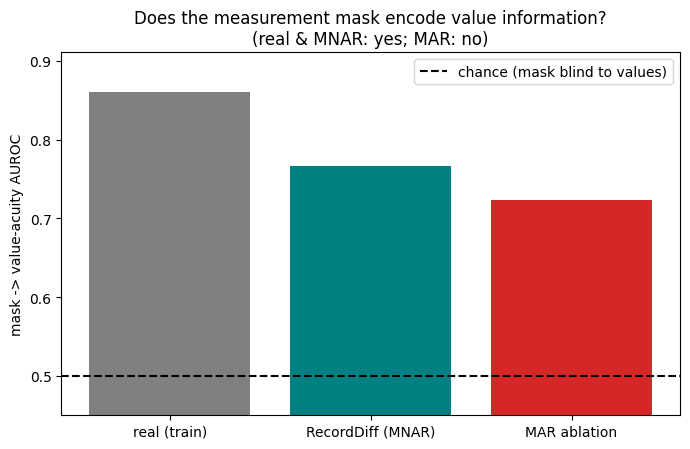


Real & MNAR >> 0.5: the mask carries value/acuity information (informative missingness).
MAR ~0.5: its mask is value-independent by construction. Only the MNAR model reproduces the
coupling -> modeling missingness as value-dependent is consequential. (Generic co-occurrence /
obs-per-record fidelity is similar for both, as expected: the mechanism lives in the coupling.)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp

def _fit_stats(y, m):
    obs = m > 0.5; cnt = np.maximum(m.sum((0, 1)), 1)
    mu = (y * obs).sum((0, 1)) / cnt
    sd = np.sqrt(np.maximum(((y - mu) ** 2 * obs).sum((0, 1)) / cnt, 1e-6))
    return mu, sd
MU, SD = _fit_stats(y_tr, m_tr)

def value_acuity(y, m):
    obs = m > 0.5
    per = (np.abs((y - MU) / SD) * obs).sum(1) / np.maximum(m.sum(1), 1)
    return per.mean(1)

def mask_knows_values(m, y):
    va = value_acuity(y, m)
    lab = (va > np.nanquantile(va, 0.75)).astype(int)
    return cross_val_score(LogisticRegression(max_iter=500), mask_features(m), lab,
                           cv=3, scoring="roc_auc").mean()

def cooc_frob(m):
    def cc(mm): f = mm.reshape(-1, V).astype(np.float32); return (f.T @ f) / f.shape[0]
    return float(np.sqrt(((cc(m_tr) - cc(m)) ** 2).sum()))
opr_ks = lambda m: float(ks_2samp(m_tr.sum((1, 2)), m.sum((1, 2))).statistic)

rows = [("real (train)", m_tr, y_tr), ("RecordDiff (MNAR)", M_mnar, Y_mnar), ("MAR ablation", M_mar, Y_mar)]
print(f"{'':20s} {'mask->acuity AUROC':>18s} {'co-occ Frob':>12s} {'obs/rec KS':>11s}")
auc_store = {}
for name, m, y in rows:
    a = mask_knows_values(m, y); auc_store[name] = a
    cf = "-" if name == "real (train)" else f"{cooc_frob(m):.3f}"
    kk = "-" if name == "real (train)" else f"{opr_ks(m):.3f}"
    print(f"{name:20s} {a:>18.3f} {cf:>12s} {kk:>11s}")

plt.figure(figsize=(7, 4.6))
names = [r[0] for r in rows]; vals = [auc_store[n] for n in names]
plt.bar(names, vals, color=["0.5", "teal", "tab:red"])
plt.axhline(0.5, ls="--", c="k", label="chance (mask blind to values)")
plt.ylabel("mask -> value-acuity AUROC"); plt.ylim(0.45, max(vals) + 0.05)
plt.title("Does the measurement mask encode value information?\n(real & MNAR: yes; MAR: no)")
plt.legend(); plt.tight_layout(); plt.show()

## 1.2 · δ-selection sensitivity (tipping-point)

variable        naive mean  RD complete  tipping delta
Lactate              2.700        2.619           0.00
Creatinine           1.527        1.537           0.00
Troponin_T           0.824        0.892           0.00
Glucose_lab        143.923      149.185           0.00


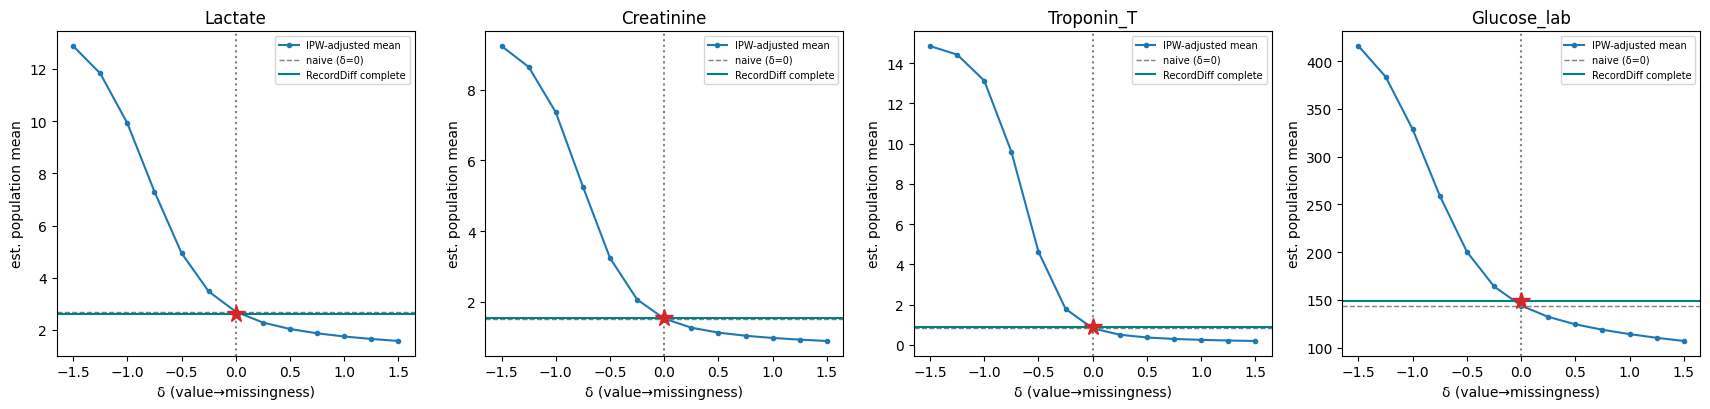


Conclusions are robust if the estimand moves little across plausible δ; the tipping δ (red star)
is the value-coupling strength needed to reconcile the recorded data with RecordDiff's complete estimate.


In [ ]:
sens = [v for v in SENS_VARS if v in VAR_NAMES][:4] or VAR_NAMES[:4]
fig, axes = plt.subplots(1, len(sens), figsize=(4.3 * len(sens), 4.2), squeeze=False)
print(f"{'variable':14s} {'naive mean':>11s} {'RD complete':>12s} {'tipping delta':>14s}")
for ax, name in zip(axes[0], sens):
    vi = VAR_NAMES.index(name)
    xo = y_tr[:, :, vi][m_tr[:, :, vi] > 0.5]
    if xo.size < 50:
        ax.set_title(f"{name}\n(too few obs)"); continue
    zo = (xo - xo.mean()) / (xo.std() + 1e-6)
    adj = np.array([delta_adjusted_mean(xo, zo, dl) for dl in DELTA_GRID])
    rd_complete = float(X_mnar[:, :, vi].mean())
    ax.plot(DELTA_GRID, adj, "-o", ms=3, color="tab:blue", label="IPW-adjusted mean")
    ax.axvline(0, ls=":", c="gray"); ax.axhline(xo.mean(), ls="--", c="gray", lw=1, label="naive (δ=0)")
    ax.axhline(rd_complete, ls="-", c="teal", lw=1.5, label="RecordDiff complete")
    tip = DELTA_GRID[int(np.argmin(np.abs(adj - rd_complete)))]
    ax.plot(tip, rd_complete, "*", ms=13, color="tab:red")
    ax.set_title(name); ax.set_xlabel("δ (value→missingness)"); ax.set_ylabel("est. population mean")
    ax.legend(fontsize=7)
    print(f"{name:14s} {xo.mean():>11.3f} {rd_complete:>12.3f} {tip:>14.2f}")
plt.tight_layout(); plt.show()

## 1.3 · Shadow-variable consistency

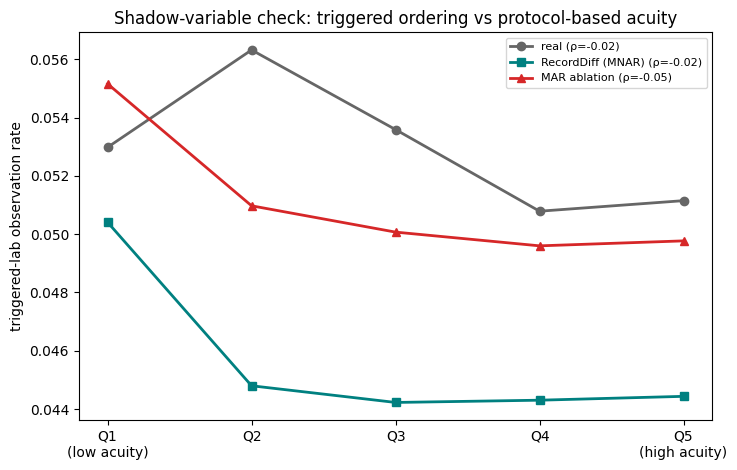

Protocol variables are recorded on nearly everyone (exogenous recording), so their peak
abnormality proxies acuity without being suspicion-driven. Real & MNAR: triggered ordering rises
with acuity (positive ρ) -> the assumed acuity->ordering mechanism is consistent with the data;
MAR: flat (ρ~0), since its policy ignores the value-latent.


In [ ]:
from scipy.stats import spearmanr
pidx = [i for i, cl in enumerate(VAR_CLASS) if cl == "protocol"]
tidx = [i for i, cl in enumerate(VAR_CLASS) if cl == "triggered"]
_po = m_tr[:, :, pidx] > 0.5; _cnt = np.maximum(m_tr[:, :, pidx].sum((0, 1)), 1)
_pmu = (y_tr[:, :, pidx] * _po).sum((0, 1)) / _cnt
_psd = np.sqrt(np.maximum(((y_tr[:, :, pidx] - _pmu) ** 2 * _po).sum((0, 1)) / _cnt, 1e-6))

def proto_acuity(y, m):
    sy, sm = y[:, :, pidx], m[:, :, pidx]; obs = sm > 0.5
    return np.where(obs, np.abs((sy - _pmu) / _psd), 0.0).max((1, 2))
def trig_rate(m):
    return m[:, :, tidx].mean((1, 2))

cohorts = [("real", m_tr, y_tr, "0.4", "-o"),
           ("RecordDiff (MNAR)", M_mnar, Y_mnar, "teal", "-s"),
           ("MAR ablation", M_mar, Y_mar, "tab:red", "-^")]
a_real = proto_acuity(y_tr, m_tr); qs = np.quantile(a_real, np.linspace(0, 1, 6))
plt.figure(figsize=(7.5, 4.8))
for name, m, y, col, mk in cohorts:
    a = proto_acuity(y, m); r = trig_rate(m)
    idx = np.clip(np.digitize(a, qs[1:-1]), 0, 4)
    curve = np.array([r[idx == b].mean() if (idx == b).any() else np.nan for b in range(5)])
    rho = spearmanr(a, r).correlation
    plt.plot(range(5), curve, mk, color=col, lw=2, label=f"{name} (ρ={rho:+.2f})")
plt.xticks(range(5), ["Q1\n(low acuity)", "Q2", "Q3", "Q4", "Q5\n(high acuity)"])
plt.ylabel("triggered-lab observation rate")
plt.title("Shadow-variable check: triggered ordering vs protocol-based acuity")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

[A · real anchor] triggered-lab ordering -> mortality_inhosp AUROC = 0.732
    triggered-rate:  survivors 0.050  |  non-survivors 0.074

[B · reproduction] triggered-mask -> value-acuity coupling (within cohort):
    real                 coupling AUROC 0.681 | triggered-rate KS vs real -
    RecordDiff (MNAR)    coupling AUROC 0.630 | triggered-rate KS vs real 0.170
    MAR ablation         coupling AUROC 0.564 | triggered-rate KS vs real 0.256


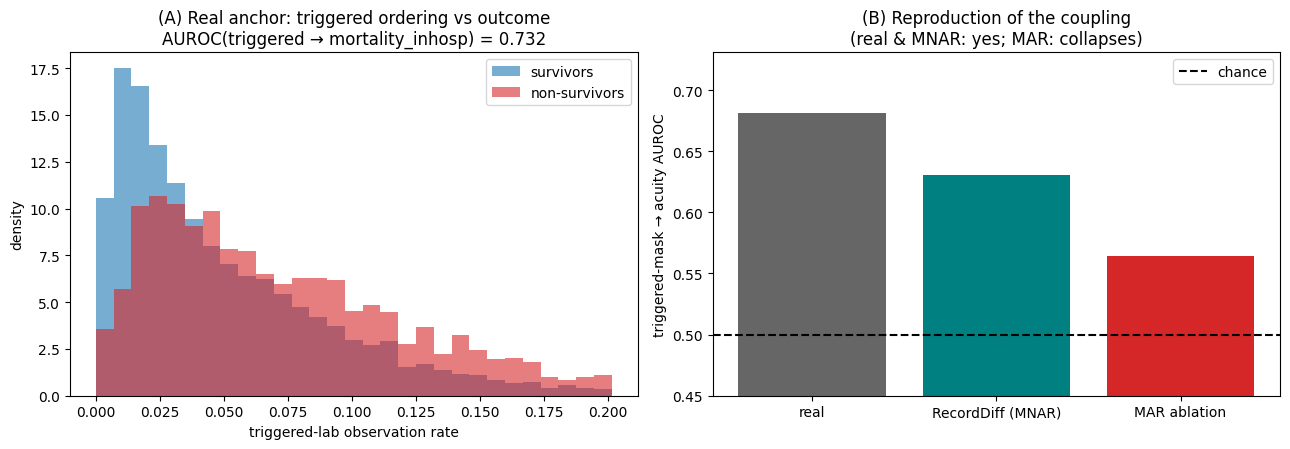


(A) grounds acuity in a real external outcome: triggered-lab ordering predicts mortality, so the
value-on-recording mechanism is real in the data. (B) RecordDiff reproduces that triggered↔acuity
coupling while the MAR ablation collapses toward chance — consistent, mechanism-specific evidence.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from scipy.stats import ks_2samp

TASK = "mortality_inhosp" if "mortality_inhosp" in labels else list(labels)[0]
tidx = [i for i, cl in enumerate(VAR_CLASS) if cl == "triggered"]
mort = labels[TASK][tr_idx]
_clf = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
trig_feats = lambda m: mask_features(m[:, :, tidx])
trig_rate  = lambda m: m[:, :, tidx].mean((1, 2))

_o = m_tr > 0.5; _c = np.maximum(m_tr.sum((0, 1)), 1)
_mu = (y_tr * _o).sum((0, 1)) / _c
_sd = np.sqrt(np.maximum(((y_tr - _mu) ** 2 * _o).sum((0, 1)) / _c, 1e-6))
def v_acuity(y, m):
    return (np.abs((y - _mu) / _sd) * (m > 0.5)).sum(1).sum(1) / np.maximum(m.sum((1, 2)), 1)

auc_anchor = cross_val_score(_clf(), trig_feats(m_tr), mort, cv=3, scoring="roc_auc").mean()
tr = trig_rate(m_tr)
print(f"[A · real anchor] triggered-lab ordering -> {TASK} AUROC = {auc_anchor:.3f}")
print(f"    triggered-rate:  survivors {tr[mort==0].mean():.3f}  |  non-survivors {tr[mort==1].mean():.3f}")

def couple(m, y):
    va = v_acuity(y, m); lab = (va > np.nanquantile(va, 0.75)).astype(int)
    return cross_val_score(_clf(), trig_feats(m), lab, cv=3, scoring="roc_auc").mean()
print("\n[B · reproduction] triggered-mask -> value-acuity coupling (within cohort):")
cohorts = [("real", m_tr, y_tr, "0.4"), ("RecordDiff (MNAR)", M_mnar, Y_mnar, "teal"),
           ("MAR ablation", M_mar, Y_mar, "tab:red")]
coup = {}
for name, m, y, _ in cohorts:
    coup[name] = couple(m, y)
    ks = "-" if name == "real" else f"{ks_2samp(trig_rate(m_tr), trig_rate(m)).statistic:.3f}"
    print(f"    {name:20s} coupling AUROC {coup[name]:.3f} | triggered-rate KS vs real {ks}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(0, np.quantile(tr, 0.99), 30)
ax[0].hist(tr[mort == 0], bins=bins, density=True, alpha=0.6, color="tab:blue", label="survivors")
ax[0].hist(tr[mort == 1], bins=bins, density=True, alpha=0.6, color="tab:red", label="non-survivors")
ax[0].set_xlabel("triggered-lab observation rate"); ax[0].set_ylabel("density")
ax[0].set_title(f"(A) Real anchor: triggered ordering vs outcome\nAUROC(triggered → {TASK}) = {auc_anchor:.3f}")
ax[0].legend()
names = [c[0] for c in cohorts]; cols = [c[3] for c in cohorts]
ax[1].bar(names, [coup[n] for n in names], color=cols)
ax[1].axhline(0.5, ls="--", c="k", label="chance"); ax[1].set_ylim(0.45, max(coup.values()) + 0.05)
ax[1].set_ylabel("triggered-mask → acuity AUROC")
ax[1].set_title("(B) Reproduction of the coupling\n(real & MNAR: yes; MAR: collapses)"); ax[1].legend()
plt.tight_layout(); plt.show()

---
# Part 2 · Dual-Channel Privacy

## 2.2 · Distance-to-Closest-Record

channel |    RecordDiff: DCR train / holdout |    memorized ctrl: train / holdout
mask    |            8.93 / 9.07            |            0.00 / 5.18           
value   |           13.08 / 13.35           |            0.12 / 8.29           
joint   |           17.53 / 17.86           |            0.12 / 11.56          


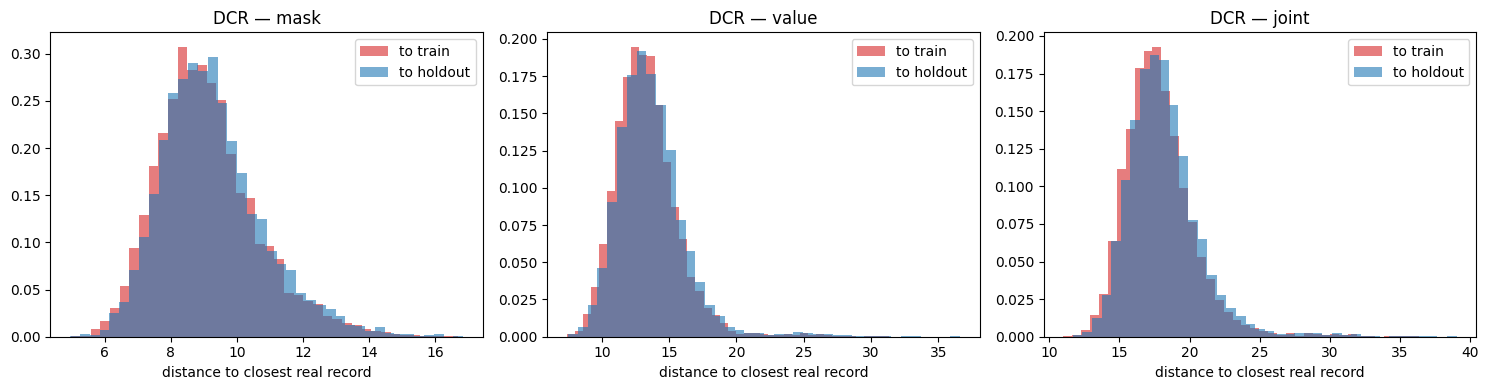

Overlapping train/holdout DCR = private (synthetic is not closer to training data).


In [ ]:
y_mem = (y_tr[sidx] + 0.01 * rng.standard_normal((len(sidx), T, V)).astype(np.float32))
M_mem, Y_mem = m_tr[sidx].copy(), (m_tr[sidx] * y_mem).astype(np.float32)
print(f"{'channel':7s} | {'RecordDiff: DCR train / holdout':>34s} | {'memorized ctrl: train / holdout':>34s}")
dcr_store = {}
for ch in ["mask", "value", "joint"]:
    ftr = channel_features(m_tr, y_tr, ch); fho = channel_features(m_ho, y_ho, ch)
    dt, dh = dcr(channel_features(M_mnar, Y_mnar, ch), ftr, fho)
    mt, mh = dcr(channel_features(M_mem, Y_mem, ch), ftr, fho)
    dcr_store[ch] = (dt, dh)
    print(f"{ch:7s} | {np.median(dt):>15.2f} / {np.median(dh):<15.2f} | {np.median(mt):>15.2f} / {np.median(mh):<15.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, ch in zip(ax, ["mask", "value", "joint"]):
    dt, dh = dcr_store[ch]
    a.hist(dt, bins=40, alpha=0.6, density=True, label="to train", color="tab:red")
    a.hist(dh, bins=40, alpha=0.6, density=True, label="to holdout", color="tab:blue")
    a.set_title(f"DCR — {ch}"); a.set_xlabel("distance to closest real record"); a.legend()
plt.tight_layout(); plt.show()
print("Overlapping train/holdout DCR = private (synthetic is not closer to training data).")

## 2.3 · Membership Inference Attack

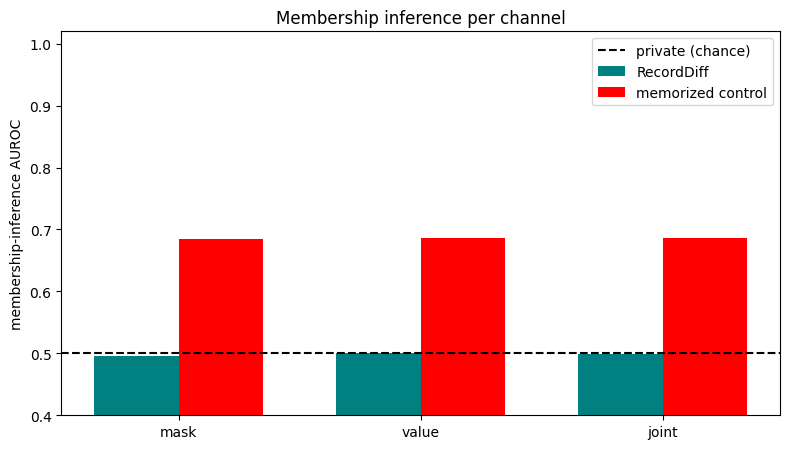

  mask   | RecordDiff 0.496 | memorized control 0.684
  value  | RecordDiff 0.500 | memorized control 0.686
  joint  | RecordDiff 0.499 | memorized control 0.686
RecordDiff near 0.50 across channels = safe; control elevated = the audit has power.


In [ ]:
labels_mia = ["mask", "value", "joint"]
rd_mia, mem_mia = [], []
for ch in labels_mia:
    ftr = channel_features(m_tr, y_tr, ch); fho = channel_features(m_ho, y_ho, ch)
    rd_mia.append(mia_auroc(ftr, fho, channel_features(M_mnar, Y_mnar, ch)))
    mem_mia.append(mia_auroc(ftr, fho, channel_features(M_mem, Y_mem, ch)))
x = np.arange(3); w = 0.35
plt.figure(figsize=(8, 4.6))
plt.bar(x - w / 2, rd_mia, w, label="RecordDiff", color="teal")
plt.bar(x + w / 2, mem_mia, w, label="memorized control", color="red")
plt.axhline(0.5, ls="--", c="k", label="private (chance)")
plt.xticks(x, labels_mia); plt.ylabel("membership-inference AUROC"); plt.ylim(0.4, 1.02); plt.legend()
plt.title("Membership inference per channel"); plt.tight_layout(); plt.show()
for ch, a, b in zip(labels_mia, rd_mia, mem_mia):
    print(f"  {ch:6s} | RecordDiff {a:.3f} | memorized control {b:.3f}")
print("RecordDiff near 0.50 across channels = safe; control elevated = the audit has power.")

## 2.4 · Mask-pattern uniqueness / k-anonymity

real mask patterns: median k 1 | k=1 (unique) 75.3% | k<5 (rare) 86.9%
synthetic->real unique-linkage rate: 0.0%  (fraction of synth masks matching exactly one real record)


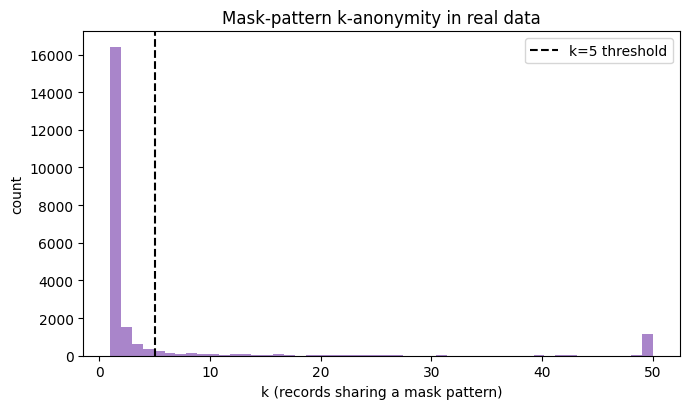

High % of low-k patterns => the mask is a genuine quasi-identifier; low linkage => synthetic
masks do not single out real patients (the risk exists in principle but RecordDiff does not realize it).


In [ ]:
pat_real = mask_pattern(m_tr, "count_bucket", cap=5)
ks = kanonymity(pat_real)
link = linkage_unique_rate(mask_pattern(M_mnar, "count_bucket", cap=5), pat_real)
print(f"real mask patterns: median k {np.median(ks):.0f} | k=1 (unique) {100*np.mean(ks==1):.1f}% | "
      f"k<5 (rare) {100*np.mean(ks<5):.1f}%")
print(f"synthetic->real unique-linkage rate: {100*link:.1f}%  (fraction of synth masks matching exactly one real record)")
plt.figure(figsize=(7, 4.2))
plt.hist(np.clip(ks, 1, 50), bins=50, color="tab:purple", alpha=0.8)
plt.axvline(5, ls="--", c="k", label="k=5 threshold")
plt.xlabel("k (records sharing a mask pattern)"); plt.ylabel("count")
plt.title("Mask-pattern k-anonymity in real data"); plt.legend(); plt.tight_layout(); plt.show()
print("High % of low-k patterns => the mask is a genuine quasi-identifier; low linkage => synthetic")
print("masks do not single out real patients (the risk exists in principle but RecordDiff does not realize it).")

## 2.5 · Attribute Inference via the mask channel

In [ ]:
sev_syn = severity_score(Y_mnar, M_mnar, VAR_CLASS)
sev_real = severity_score(y_ho, m_ho, VAR_CLASS)
thr = np.nanquantile(sev_syn, 0.75)
a_syn = (sev_syn > thr).astype(int)
a_real = (sev_real > np.nanquantile(sev_real, 0.75)).astype(int)
print(f"{'attacker features':16s} {'attribute-inference AUROC (test on real)':>42s}")
for ch in ["mask", "value", "joint"]:
    auc = attribute_inference_auroc(M_mnar, Y_mnar, a_syn, m_ho, y_ho, a_real, ch, seed=SEED)
    print(f"{ch:16s} {auc:>42.3f}")
print("\nMask-only AUROC > 0.5 => the measurement pattern alone leaks acuity status. This is a real,")
print("mask-specific privacy consideration; report it honestly alongside the low MIA (leakage of *membership*")
print("is what matters for re-identification, and that is near chance).")

attacker features   attribute-inference AUROC (test on real)
mask                                                  0.594
value                                                 0.908
joint                                                 0.915

Mask-only AUROC > 0.5 => the measurement pattern alone leaks acuity status. This is a real,
mask-specific privacy consideration; report it honestly alongside the low MIA (leakage of *membership*
is what matters for re-identification, and that is near chance).


## 2.6 · Utility–Privacy frontier

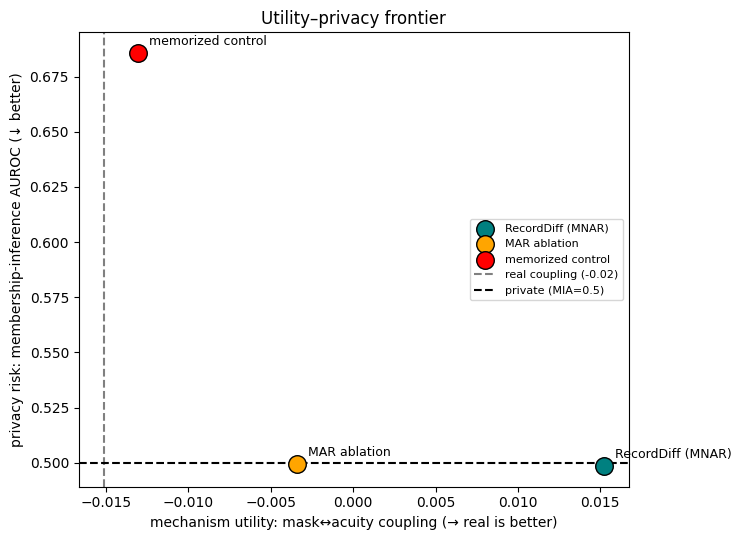

Target: RecordDiff near the real coupling (high utility) AND near MIA 0.5 (low risk) — unlike the
memorized control (high risk) and the MAR ablation (low utility).


In [ ]:
def joint_mia(M, Y):
    return mia_auroc(channel_features(m_tr, y_tr, "joint"), channel_features(m_ho, y_ho, "joint"),
                     channel_features(M, Y, "joint"))
pts = {
    "RecordDiff (MNAR)": (coupling(M_mnar, Y_mnar), joint_mia(M_mnar, Y_mnar), "teal"),
    "MAR ablation":      (coupling(M_mar, Y_mar),  joint_mia(M_mar, Y_mar),   "orange"),
    "memorized control": (coupling(M_mem, Y_mem),  joint_mia(M_mem, Y_mem),   "red"),
}
real_c = coupling(m_tr, y_tr)
plt.figure(figsize=(7.5, 5.5))
for name, (u, p, col) in pts.items():
    plt.scatter(u, p, s=160, color=col, label=name, edgecolor="k", zorder=3)
    plt.annotate(name, (u, p), textcoords="offset points", xytext=(8, 6), fontsize=9)
plt.axvline(real_c, ls="--", c="0.5", label=f"real coupling ({real_c:.2f})")
plt.axhline(0.5, ls="--", c="k", label="private (MIA=0.5)")
plt.xlabel("mechanism utility: mask↔acuity coupling (→ real is better)")
plt.ylabel("privacy risk: membership-inference AUROC (↓ better)")
plt.title("Utility–privacy frontier"); plt.legend(fontsize=8, loc="center right")
plt.tight_layout(); plt.show()
print("Target: RecordDiff near the real coupling (high utility) AND near MIA 0.5 (low risk) — unlike the")
print("memorized control (high risk) and the MAR ablation (low utility).")